# Adam: A Method for Stochastic Optimization

**Paper:** Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR 2015.  
**arXiv:** https://arxiv.org/abs/1412.6980

This notebook implements the Adam update rule from scratch in NumPy and compares it against vanilla SGD and RMSProp on a toy 2-D loss surface with a contour plot and animation.


## 1. Imports and reproducibility

We only need `numpy`, `matplotlib`, and `PIL` (standard in Colab). We fix the random seed for reproducibility.


In [1]:
import os
import shutil
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

np.random.seed(42)
TMP_DIR = Path('/tmp/adam_frames')
TMP_DIR.mkdir(parents=True, exist_ok=True)

print('numpy', np.__version__)
print('matplotlib', matplotlib.__version__)
print('PIL OK')

numpy 2.0.2
matplotlib 3.10.0
PIL OK


## 2. Toy 2-D loss surface and gradient

We use a **tilted quadratic valley**:

$$L(x, y) = (x - 1)^2 + 5\,(y - 0.5x)^2$$

The global minimum is at $(x, y) = (1, 0.5)$. The valley has very different curvature along the two axes, which makes a single global learning rate painful and highlights the benefit of per-parameter adaptive scaling (RMSProp / Adam).

Shapes:
- `theta` is `(2,)`
- gradient is `(2,)`
- loss is scalar


In [2]:
def loss_fn(theta):
    x, y = theta[0], theta[1]
    return (x - 1.0)**2 + 5.0 * (y - 0.5 * x)**2

def grad_fn(theta):
    x, y = theta[0], theta[1]
    dx = 2.0 * (x - 1.0) + 5.0 * (y - 0.5 * x) * (-1.0)
    dy = 10.0 * (y - 0.5 * x)
    return np.array([dx, dy])

xs = np.linspace(-3, 3, 200)
ys = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xs, ys)
Z = (X - 1.0)**2 + 5.0 * (Y - 0.5 * X)**2

print('Grid shape:', Z.shape)
print('Minimum:', (1.0, 0.5), 'loss', loss_fn(np.array([1.0, 0.5])))

Grid shape: (200, 200)
Minimum: (1.0, 0.5) loss 0.0


## 3. Optimizer implementations from scratch

The Adam update equations (elementwise):

1. $m_t = eta_1 \, m_{t-1} + (1 - eta_1) \, g_t$
2. $v_t = eta_2 \, v_{t-1} + (1 - eta_2) \, g_t^2$
3. $\hat{m}_t = m_t / (1 - eta_1^t)$  &nbsp; *(bias correction)*
4. $\hat{v}_t = v_t / (1 - eta_2^t)$  &nbsp; *(bias correction)*
5. $	heta_t = 	heta_{t-1} - lpha \, \hat{m}_t / (\sqrt{\hat{v}_t} + arepsilon)$


In [3]:
def sgd_step(theta, lr):
    return theta - lr * grad_fn(theta)

def rmsprop_step(theta, lr, state, beta=0.9, eps=1e-8):
    g = grad_fn(theta)
    v = state.get('v', np.zeros_like(theta))
    v = beta * v + (1.0 - beta) * g * g
    state['v'] = v
    return theta - lr * g / (np.sqrt(v) + eps)

def adam_step(theta, lr, state, t, beta1=0.9, beta2=0.999, eps=1e-8):
    g = grad_fn(theta)
    m = state.get('m', np.zeros_like(theta))
    v = state.get('v', np.zeros_like(theta))
    m = beta1 * m + (1.0 - beta1) * g
    v = beta2 * v + (1.0 - beta2) * g * g
    state['m'] = m
    state['v'] = v
    m_hat = m / (1.0 - beta1**t)
    v_hat = v / (1.0 - beta2**t)
    return theta - lr * m_hat / (np.sqrt(v_hat) + eps)

print('Optimizers defined: sgd_step, rmsprop_step, adam_step')

Optimizers defined: sgd_step, rmsprop_step, adam_step


## 4. Training loop

All three optimizers start from the same point `[-2.0, 2.0]` and run for the same number of steps so the comparison is fair.


In [4]:
def optimize(opt_name, n_iter=200, init=None):
    if init is None:
        init = np.array([-2.0, 2.0])
    theta = init.copy().astype(float)
    history = [theta.copy()]
    losses = [loss_fn(theta)]
    state = {}
    for t in range(1, n_iter + 1):
        if opt_name == 'sgd':
            theta = sgd_step(theta, lr=0.02)
        elif opt_name == 'rmsprop':
            theta = rmsprop_step(theta, lr=0.05, state=state, beta=0.9, eps=1e-8)
        elif opt_name == 'adam':
            theta = adam_step(theta, lr=0.05, state=state, t=t, beta1=0.9, beta2=0.999, eps=1e-8)
        else:
            raise ValueError(opt_name)
        history.append(theta.copy())
        losses.append(loss_fn(theta))
    return np.array(history), np.array(losses)

hist_sgd, loss_sgd = optimize('sgd')
hist_rms, loss_rms = optimize('rmsprop')
hist_adam, loss_adam = optimize('adam')

print('SGD    final loss:', loss_sgd[-1])
print('RMSProp final loss:', loss_rms[-1])
print('Adam   final loss:', loss_adam[-1])
print('History shapes:', hist_sgd.shape, hist_rms.shape, hist_adam.shape)

SGD    final loss: 9.108523763870072e-06
RMSProp final loss: 0.006749463063233305
Adam   final loss: 0.03740197451617636
History shapes: (201, 2) (201, 2) (201, 2)


## 5. Static contour plot of trajectories


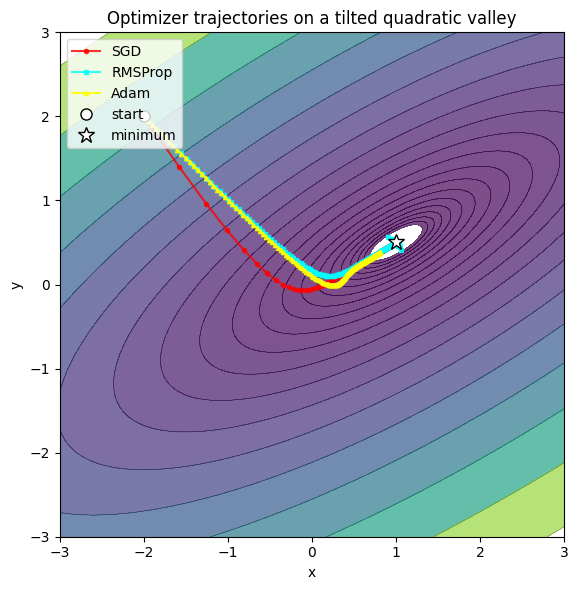

Saved static plot: /tmp/adam_frames/trajectories.png


In [5]:
levels = np.logspace(-1, 2, 20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)
ax.contour(X, Y, Z, levels=levels, colors='black', linewidths=0.5, alpha=0.3)

ax.plot(hist_sgd[:, 0], hist_sgd[:, 1], 'o-', color='red', markersize=3, label='SGD', alpha=0.8)
ax.plot(hist_rms[:, 0], hist_rms[:, 1], 's-', color='cyan', markersize=3, label='RMSProp', alpha=0.8)
ax.plot(hist_adam[:, 0], hist_adam[:, 1], '^-', color='yellow', markersize=3, label='Adam', alpha=0.9)

ax.plot(hist_sgd[0, 0], hist_sgd[0, 1], 'o', color='white', markersize=8, markeredgecolor='black', label='start')
ax.plot(1.0, 0.5, '*', color='white', markersize=12, markeredgecolor='black', label='minimum')

ax.set_title('Optimizer trajectories on a tilted quadratic valley')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper left')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
static_path = TMP_DIR / 'trajectories.png'
plt.savefig(static_path, dpi=150)
plt.show()
print('Saved static plot:', static_path)

## 6. Animation of the Adam trajectory

We render frames at every other step, build a GIF with Pillow, and embed it inline.


Saved GIF: /tmp/adam_frames/adam_trajectory.gif frames: 101


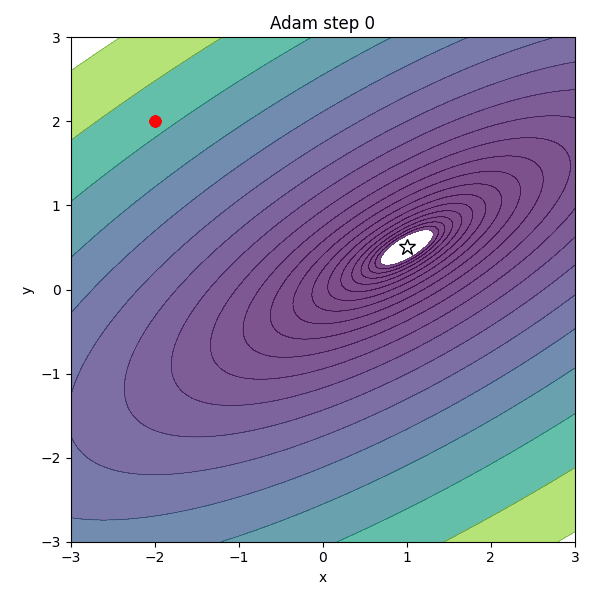

In [6]:
frames_dir = TMP_DIR / 'frames'
frames_dir.mkdir(exist_ok=True)

# clean old frames
for f in frames_dir.glob('*.png'):
    f.unlink()

frame_paths = []
for i, theta in enumerate(hist_adam):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)
    ax.contour(X, Y, Z, levels=levels, colors='black', linewidths=0.5, alpha=0.3)
    ax.plot(hist_adam[:i+1, 0], hist_adam[:i+1, 1], 'o-', color='yellow', markersize=3)
    ax.plot(hist_adam[i, 0], hist_adam[i, 1], 'o', color='red', markersize=8)
    ax.plot(1.0, 0.5, '*', color='white', markersize=12, markeredgecolor='black')
    ax.set_title(f'Adam step {i}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    fp = frames_dir / f'frame_{i:03d}.png'
    plt.savefig(fp, dpi=100)
    plt.close(fig)
    frame_paths.append(str(fp))

# Save GIF using every second frame to keep size small
gif_path = TMP_DIR / 'adam_trajectory.gif'
images = [Image.open(p).convert('RGB') for p in frame_paths]
images[::2][0].save(
    gif_path,
    save_all=True,
    append_images=images[::2][1:],
    duration=80,
    loop=0
)
print('Saved GIF:', gif_path, 'frames:', len(images[::2]))

# Embed the GIF in the notebook output
from IPython.display import Image as IPImage, display
display(IPImage(filename=str(gif_path)))

## 7. Result summary


In [7]:
print('Best minimum: (1.0, 0.5), loss 0')
print()
print('SGD trajectory:')
print(' - Start:', hist_sgd[0])
print(' - End:  ', hist_sgd[-1])
print(' - Final loss:', loss_sgd[-1])
print()
print('RMSProp trajectory:')
print(' - Start:', hist_rms[0])
print(' - End:  ', hist_rms[-1])
print(' - Final loss:', loss_rms[-1])
print()
print('Adam trajectory:')
print(' - Start:', hist_adam[0])
print(' - End:  ', hist_adam[-1])
print(' - Final loss:', loss_adam[-1])
print()
print('Adam combines momentum (first moment) with per-parameter adaptive scaling (second moment) and bias correction, so it navigates the narrow valley more directly than plain SGD and with more stable early steps than RMSProp.')

Best minimum: (1.0, 0.5), loss 0

SGD trajectory:
 - Start: [-2.  2.]
 - End:   [0.99704292 0.49825157]
 - Final loss: 9.108523763870072e-06

RMSProp trajectory:
 - Start: [-2.  2.]
 - End:   [1.02347283 0.47652707]
 - Final loss: 0.006749463063233305

Adam trajectory:
 - Start: [-2.  2.]
 - End:   [0.81292736 0.38452831]
 - Final loss: 0.03740197451617636

Adam combines momentum (first moment) with per-parameter adaptive scaling (second moment) and bias correction, so it navigates the narrow valley more directly than plain SGD and with more stable early steps than RMSProp.


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
